In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/energy_data_set.csv")
print(df.shape)
print(df.columns.tolist())

(19735, 29)
['date', 'Appliances', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'rv1', 'rv2']


In [2]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").set_index("date")

print("Date range:", df.index.min(), "to", df.index.max())
print("Missing values:", df.isna().sum().sum())
print("Duplicate timestamps:", df.index.duplicated().sum())
print(df.index.to_series().diff().value_counts().head())
print(df["Appliances"].describe())

Date range: 2016-01-11 17:00:00 to 2016-05-27 18:00:00
Missing values: 0
Duplicate timestamps: 0
date
0 days 00:10:00    19734
Name: count, dtype: int64
count    19735.000000
mean        97.694958
std        102.524891
min         10.000000
25%         50.000000
50%         60.000000
75%        100.000000
max       1080.000000
Name: Appliances, dtype: float64


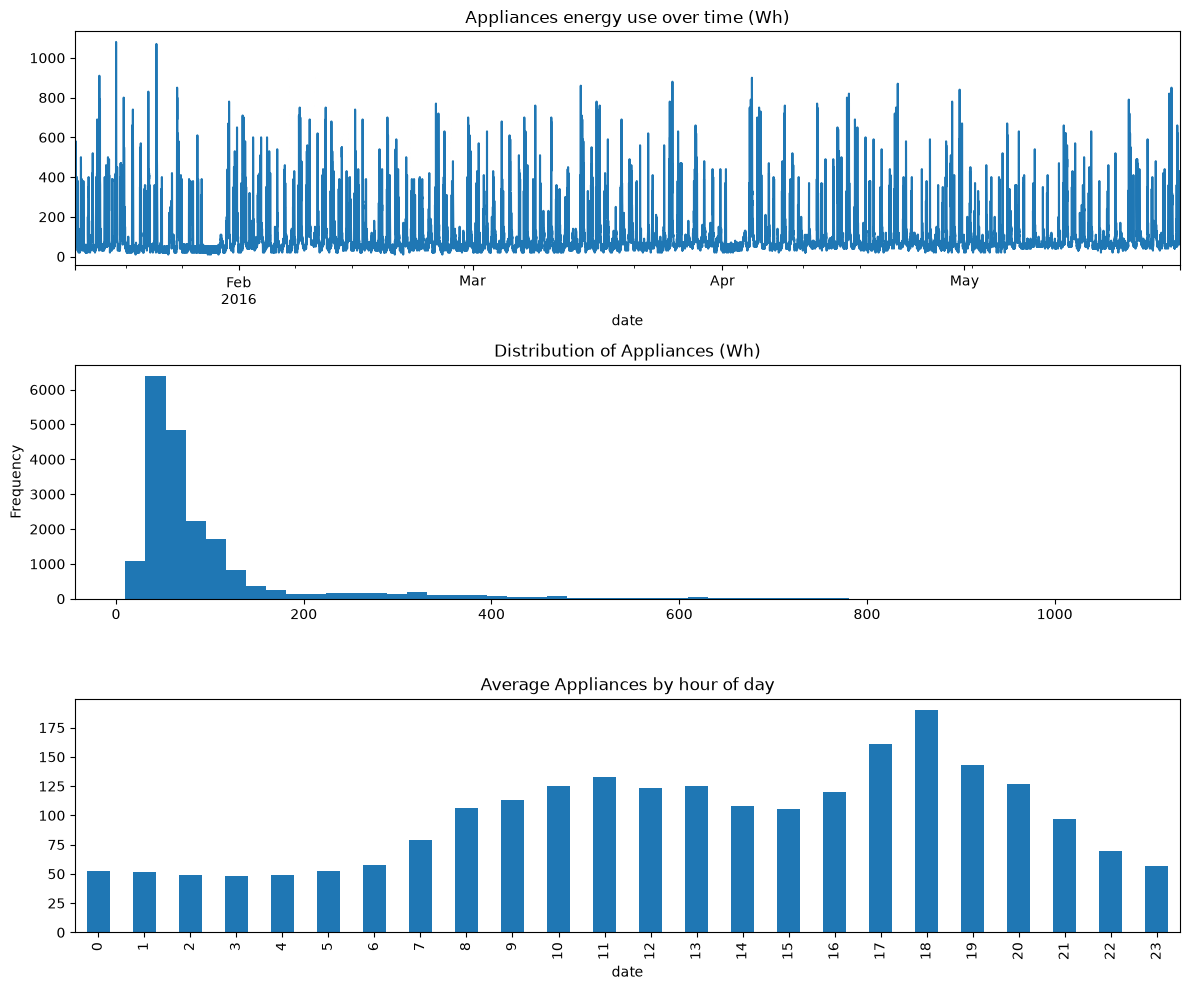

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

df["Appliances"].plot(ax=axes[0], title="Appliances energy use over time (Wh)")
df["Appliances"].plot(kind="hist", bins=50, ax=axes[1], title="Distribution of Appliances (Wh)")
df.groupby(df.index.hour)["Appliances"].mean().plot(
    kind="bar", ax=axes[2], title="Average Appliances by hour of day"
)

plt.tight_layout()
plt.show()

IQR upper bound: 175 Wh
Rows above it: 2138 (10.8%)


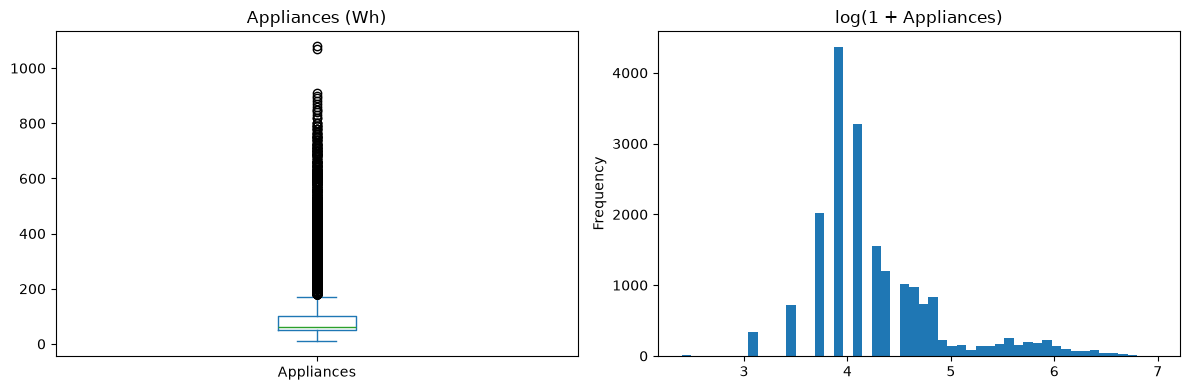

In [4]:
import numpy as np

q1, q3 = df["Appliances"].quantile([0.25, 0.75])
upper = q3 + 1.5 * (q3 - q1)
n_out = (df["Appliances"] > upper).sum()
print(f"IQR upper bound: {upper:.0f} Wh")
print(f"Rows above it: {n_out} ({n_out / len(df):.1%})")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["Appliances"].plot(kind="box", ax=axes[0], title="Appliances (Wh)")
np.log1p(df["Appliances"]).plot(kind="hist", bins=50, ax=axes[1], title="log(1 + Appliances)")
plt.tight_layout()
plt.show()

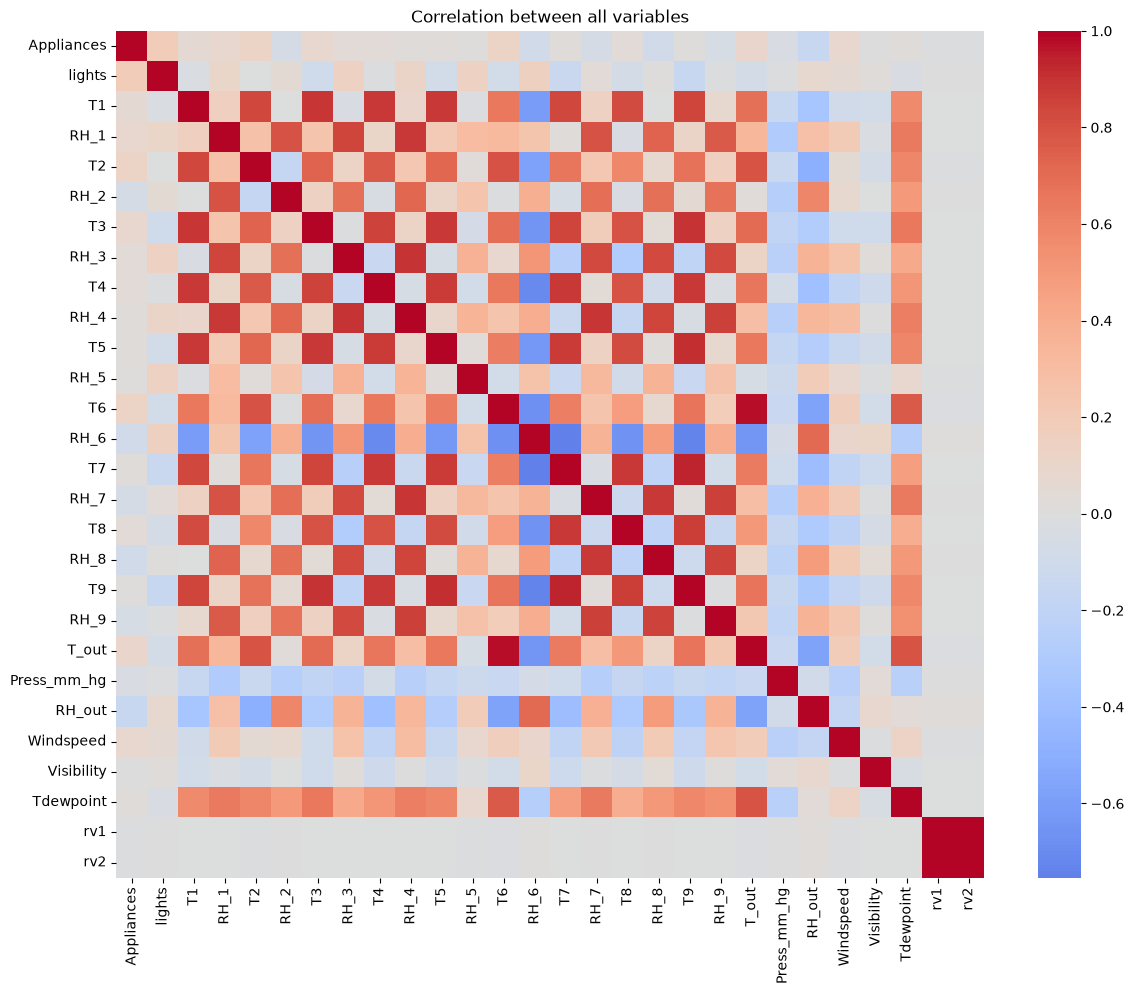

Appliances     1.000000
lights         0.197278
T2             0.120073
T6             0.117638
T_out          0.099155
Windspeed      0.087122
RH_1           0.086031
T3             0.085060
T1             0.055447
T4             0.040281
T8             0.039572
RH_3           0.036292
T7             0.025801
T5             0.019760
RH_4           0.016965
Tdewpoint      0.015353
T9             0.010010
RH_5           0.006955
Visibility     0.000230
rv1           -0.011145
rv2           -0.011145
Press_mm_hg   -0.034885
RH_9          -0.051462
RH_7          -0.055642
RH_2          -0.060465
RH_6          -0.083178
RH_8          -0.094039
RH_out        -0.152282
Name: Appliances, dtype: float64


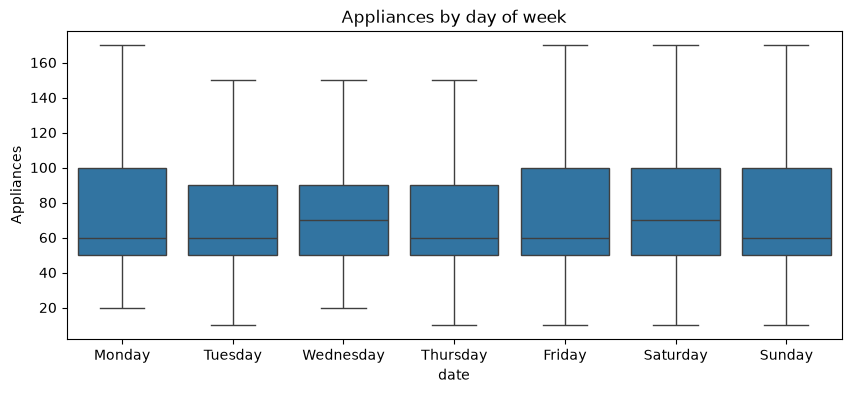

In [5]:
import seaborn as sns

plt.figure(figsize=(14, 11))
sns.heatmap(df.corr(), cmap="coolwarm", center=0)
plt.title("Correlation between all variables")
plt.show()

print(df.corr()["Appliances"].sort_values(ascending=False))

days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
plt.figure(figsize=(10, 4))
sns.boxplot(x=df.index.day_name(), y=df["Appliances"], order=days, showfliers=False)
plt.title("Appliances by day of week")
plt.show()

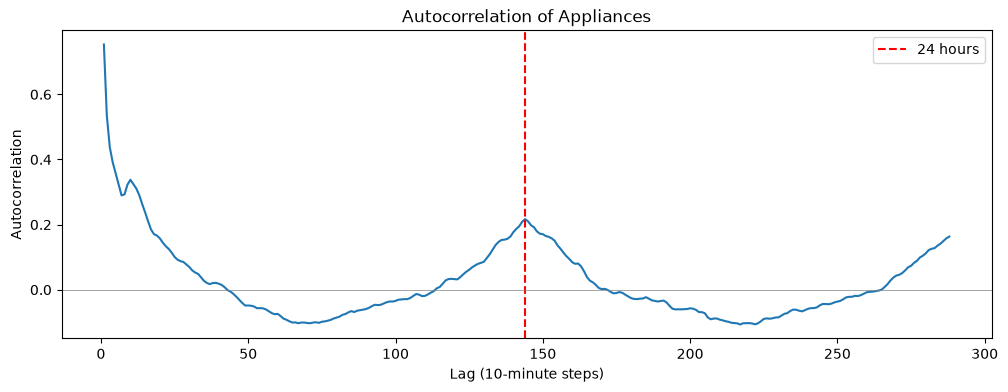

lag   1 (  10 min): 0.753
lag   2 (  20 min): 0.534
lag   3 (  30 min): 0.438
lag   6 (  60 min): 0.324
lag  12 ( 120 min): 0.311
lag  18 ( 180 min): 0.171
lag  36 ( 360 min): 0.021
lag  72 ( 720 min): -0.101
lag 144 (1440 min): 0.217


In [6]:
lags = range(1, 289)   # up to 48 hours (288 steps of 10 minutes)
acf = [df["Appliances"].autocorr(lag=k) for k in lags]

plt.figure(figsize=(12, 4))
plt.plot(lags, acf)
plt.axvline(144, color="red", linestyle="--", label="24 hours")
plt.axhline(0, color="grey", linewidth=0.5)
plt.xlabel("Lag (10-minute steps)")
plt.ylabel("Autocorrelation")
plt.title("Autocorrelation of Appliances")
plt.legend()
plt.show()

for k in [1, 2, 3, 6, 12, 18, 36, 72, 144]:
    print(f"lag {k:>3} ({k * 10:>4} min): {df['Appliances'].autocorr(lag=k):.3f}")

In [7]:
import sys
sys.path.append("../src")
from feature_engineering import build_features

features = build_features(df)
print(features.shape)
print(features.columns.tolist())

features.to_csv("../data/processed/features.csv")

(19591, 52)
['Appliances', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'app_lag_1', 'app_lag_2', 'app_lag_3', 'app_lag_6', 'app_lag_12', 'app_lag_144', 'app_diff_1', 'app_roll_mean_1h', 'app_roll_std_1h', 'app_roll_max_1h', 'app_roll_mean_3h', 'app_roll_std_3h', 'app_roll_max_3h', 'indoor_temp_mean', 'indoor_rh_mean', 'temp_gap_in_out', 'temp_x_rh', 'kitchen_rh_excess', 'NSM', 'hour_sin', 'hour_cos', 'day_of_week', 'is_weekend', 'is_holiday', 'weekend_hour_sin', 'weekend_hour_cos']


In [8]:
from data_preprocessing import chronological_split, split_xy, scale_features, to_wh

train, val, test = chronological_split(features)
for name, part in [("train", train), ("val", val), ("test", test)]:
    print(f"{name:<5} {len(part):>6} rows   {part.index.min()}  to  {part.index.max()}")

X_train, y_train = split_xy(train)
X_val, y_val = split_xy(val)
X_test, y_test = split_xy(test)
X_train_s, X_val_s, X_test_s, scaler = scale_features(X_train, X_val, X_test)
print("Features:", X_train_s.shape[1])

train  13713 rows   2016-01-12 17:00:00  to  2016-04-16 22:20:00
val     1959 rows   2016-04-16 22:30:00  to  2016-04-30 12:50:00
test    3919 rows   2016-04-30 13:00:00  to  2016-05-27 18:00:00
Features: 51


                      MAE   RMSE  MAPE %    R2
model                                         
Naive (last value)  26.05  65.19   21.86  0.45
Linear Regression   27.26  66.49   22.12  0.43
Random Forest       26.51  58.30   23.19  0.56


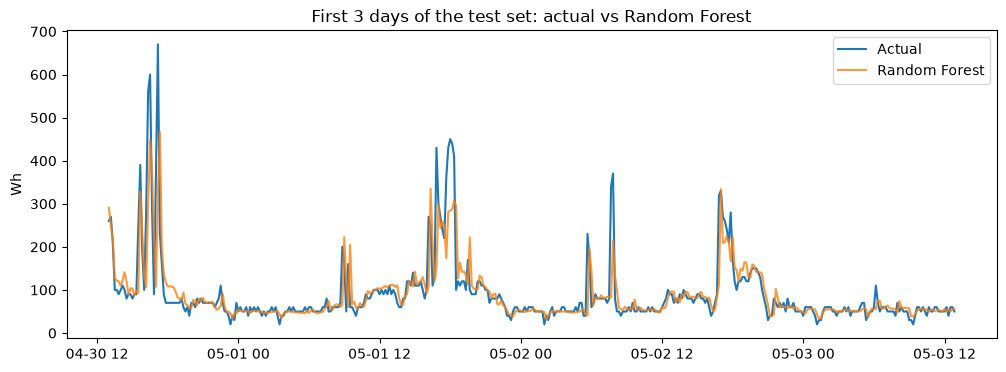

In [9]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def evaluate(name, actual_wh, predicted_wh):
    """Return MAE, RMSE, MAPE and R2 for one model, all on the original Wh scale."""
    return {
        "model": name,
        "MAE": mean_absolute_error(actual_wh, predicted_wh),
        "RMSE": np.sqrt(mean_squared_error(actual_wh, predicted_wh)),
        "MAPE %": np.mean(np.abs((actual_wh - predicted_wh) / actual_wh)) * 100,
        "R2": r2_score(actual_wh, predicted_wh),
    }


actual = test["Appliances"].values
results = []

# Naive baseline: predict that the next reading equals the last one.
results.append(evaluate("Naive (last value)", actual, X_test["app_lag_1"].values))

linear = LinearRegression().fit(X_train_s, y_train)
results.append(evaluate("Linear Regression", actual, to_wh(linear.predict(X_test_s))))

forest = RandomForestRegressor(n_estimators=200, min_samples_leaf=5, n_jobs=-1, random_state=42)
forest.fit(X_train_s, y_train)
forest_pred = to_wh(forest.predict(X_test_s))
results.append(evaluate("Random Forest", actual, forest_pred))

baseline_results = pd.DataFrame(results).set_index("model").round(2)
print(baseline_results)

plt.figure(figsize=(12, 4))
plt.plot(test.index[:432], actual[:432], label="Actual")
plt.plot(test.index[:432], forest_pred[:432], label="Random Forest", alpha=0.8)
plt.title("First 3 days of the test set: actual vs Random Forest")
plt.ylabel("Wh")
plt.legend()
plt.show()